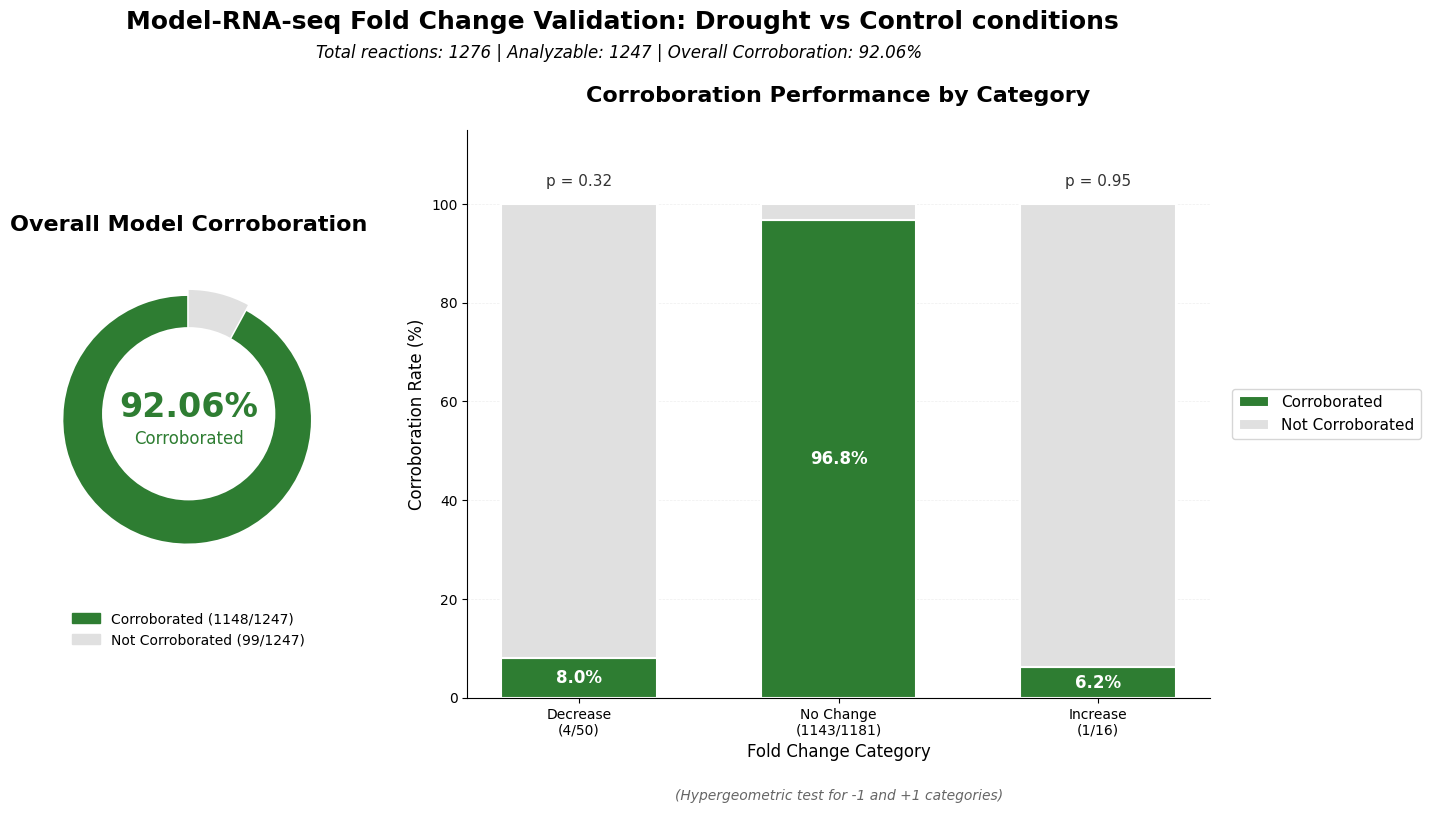

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Circle
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec

# Set up the figure with a custom layout - increased height
fig = plt.figure(figsize=(14, 8))

# Define color scheme
validated_color = '#2E7D32'  # Dark green
not_validated_color = '#E0E0E0'  # Light gray

# Your data
total_reactions = 1276
analyzable_reactions = 1247
validated_reactions = 1148
validation_pct = 92.06

# Category data with hypergeometric p-values
categories = {
    -1: {'validated': 4, 'total': 50, 'pct': 8, 'label': 'Decrease', 'p_value': 0.3195},
    0: {'validated': 1143, 'total': 1181, 'pct': 96.8, 'label': 'No Change', 'p_value': None},
    1: {'validated': 1, 'total': 16, 'pct': 6.2, 'label': 'Increase', 'p_value': 0.9513}
}

# Create custom gridspec for 1/3 and 2/3 width distribution
gs = gridspec.GridSpec(1, 3, figure=fig, wspace=0.4)

# === Panel A: Validation Overview (Donut Chart) - 1/3 width ===
ax1 = fig.add_subplot(gs[0, 0])  # Takes first column

# Donut chart data
sizes = [validation_pct, 100 - validation_pct]
colors = [validated_color, not_validated_color]
explode = (0.05, 0)  # Slightly separate the validated slice

# Create donut
wedges, texts, autotexts = ax1.pie(sizes, colors=colors, labels=['', ''],
                                     autopct='', startangle=90,
                                     explode=explode)

# Make it a donut by adding a white circle in the center
centre_circle = Circle((0, 0), 0.70, fc='white')
ax1.add_artist(centre_circle)

# Add center text with better sizing
ax1.text(0, 0.05, f'{validation_pct}%', ha='center', va='center',
         fontsize=24, weight='bold', color=validated_color)
ax1.text(0, -0.2, 'Corroborated', ha='center', va='center',
         fontsize=12, color=validated_color)

# Add title
ax1.set_title('Overall Model Corroboration', fontsize=16, weight='bold', pad=20)

# Add legend below the donut
legend_elements = [
    mpatches.Patch(color=validated_color, label=f'Corroborated ({validated_reactions}/{analyzable_reactions})'),
    mpatches.Patch(color=not_validated_color, label=f'Not Corroborated ({analyzable_reactions - validated_reactions}/{analyzable_reactions})')
]
ax1.legend(handles=legend_elements, loc='upper center', bbox_to_anchor=(0.5, -0.1),
          ncol=1, fontsize=10, frameon=False)

# === Panel B: Category-Specific Performance with P-values - 2/3 width ===
ax2 = fig.add_subplot(gs[0, 1:])  # Takes columns 2 and 3

# Prepare data for bar chart
categories_list = [-1, 0, 1]
category_labels = [categories[cat]['label'] for cat in categories_list]
# Create labels with counts on second line
category_labels_with_counts = [f"{categories[cat]['label']}\n({categories[cat]['validated']}/{categories[cat]['total']})"
                               for cat in categories_list]
validation_rates = [categories[cat]['pct'] for cat in categories_list]
not_validated_rates = [100 - rate for rate in validation_rates]

# Set up bar positions
x = np.arange(len(categories_list))
width = 0.6

# Create stacked bars with better styling
bars1 = ax2.bar(x, validation_rates, width, label='Corroborated',
                color=validated_color, edgecolor='white', linewidth=1.5)
bars2 = ax2.bar(x, not_validated_rates, width, bottom=validation_rates,
                label='Not Corroborated', color=not_validated_color,
                edgecolor='white', linewidth=1.5)

# Add value labels on bars
for i, (cat, bar) in enumerate(zip(categories_list, bars1)):
    height = bar.get_height()
    # Only add percentage if the bar is tall enough
    if height > 5:
        ax2.text(bar.get_x() + bar.get_width()/2, height/2, f'{height:.1f}%',
                ha='center', va='center', fontsize=12, weight='bold', color='white')

# Add p-values above bars for -1 and +1 categories only
for i, cat in enumerate(categories_list):
    if categories[cat]['p_value'] is not None:  # Only for -1 and +1
        bar_height = 100  # Use full height since bars are stacked to 100
        p_val = categories[cat]['p_value']

        # Position p-value above the bar
        y_position = bar_height + 3

        # Format p-value text
        if p_val < 0.001:
            p_text = 'p < 0.001'
            fontweight = 'bold'
            color = '#d62728'  # Red for significant
        elif p_val < 0.05:
            p_text = f'p = {p_val:.3f}'
            fontweight = 'bold'
            color = '#d62728'  # Red for significant
        else:
            p_text = f'p = {p_val:.2f}'
            fontweight = 'normal'
            color = '#333333'

        # Add p-value text
        ax2.text(x[i], y_position, p_text,
                ha='center', va='bottom', fontsize=11,
                weight=fontweight, color=color)



# Customize the plot
ax2.set_ylabel('Corroboration Rate (%)', fontsize=12)
ax2.set_xlabel('Fold Change Category', fontsize=12)
ax2.set_title('Corroboration Performance by Category', fontsize=16, weight='bold', pad=20)
ax2.text(0.5, -0.18, '(Hypergeometric test for -1 and +1 categories)',
         transform=ax2.transAxes, ha='center', fontsize=10, style='italic', color='#666666')
ax2.set_xticks(x)
ax2.set_xticklabels(category_labels_with_counts)
ax2.set_ylim(0, 115)  # To accommodate p-value labels
# Move legend to the right side, outside the plot area
ax2.legend(loc='center left', frameon=True, fancybox=True, shadow=False,
           bbox_to_anchor=(1.02, 0.5), fontsize=11)

# Add subtle grid for better readability
ax2.grid(True, axis='y', alpha=0.2, linestyle='--', linewidth=0.5)
ax2.set_axisbelow(True)  # Put grid behind bars

# Make the plot look cleaner
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

# === Overall figure adjustments ===
# Add main title with proper spacing
fig.suptitle('Model-RNA-seq Fold Change Validation: Drought vs Control conditions',
             fontsize=18, weight='bold', y=0.98)

# Add subtitle with key stats
fig.text(0.5, 0.92,
         f'Total reactions: {total_reactions} | Analyzable: {analyzable_reactions} | ' +
         f'Overall Corroboration: {validation_pct}% ',
         ha='center', fontsize=12, style='italic')

# Manual spacing adjustment - adjusted right margin to make room for legend
plt.subplots_adjust(left=0.08, right=0.92, top=0.83, bottom=0.12, wspace=0.4)

# Optional: Save the figure
plt.savefig('model_validation_dashboard_with_pvalues.png', dpi=300, bbox_inches='tight')
plt.savefig('model_validation_dashboard_with_pvalues.pdf', bbox_inches='tight')  # For publication
plt.show()

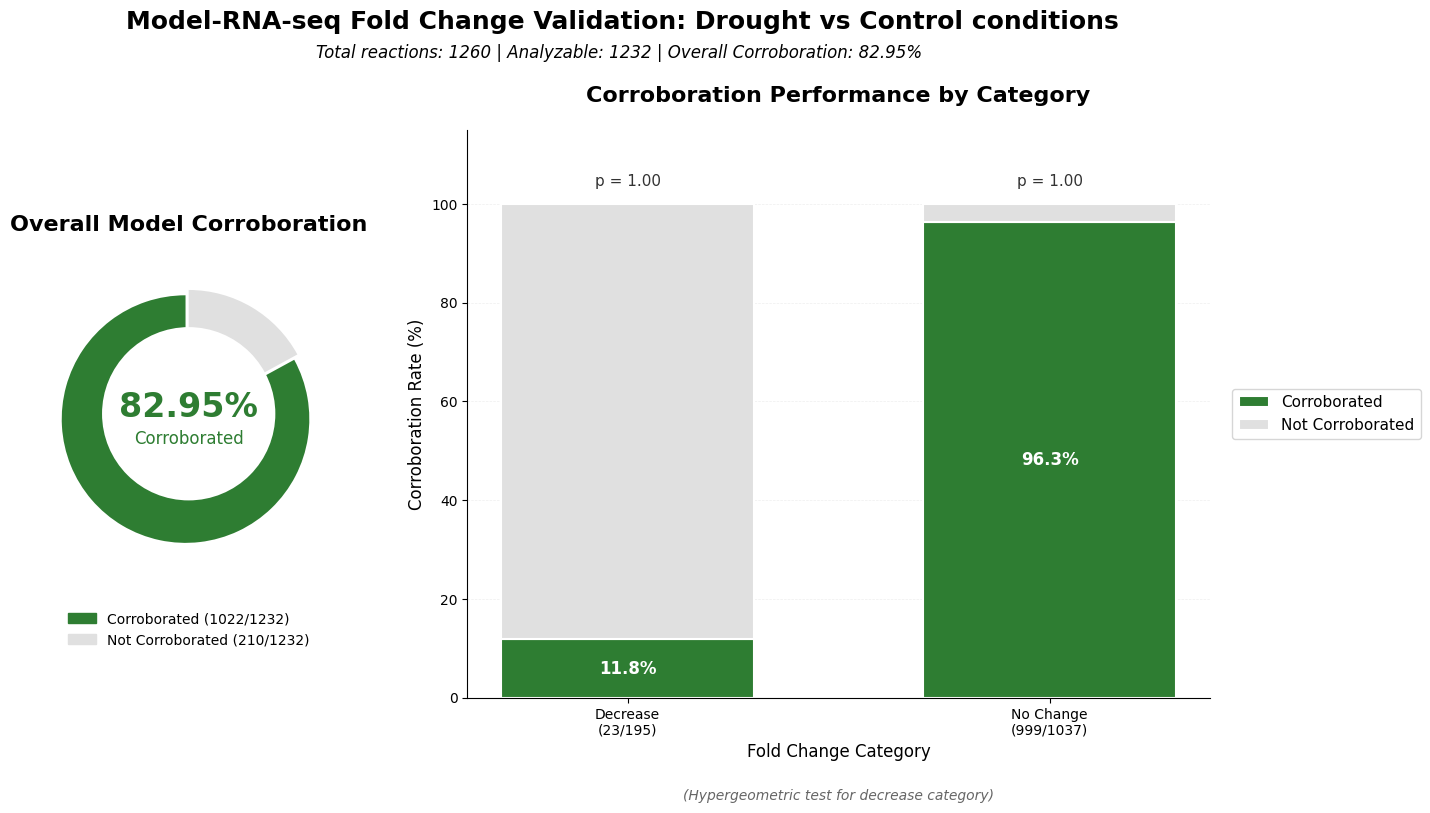

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Circle
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec

# Set up the figure with a custom layout - increased height
fig = plt.figure(figsize=(14, 8))

# Define color scheme
validated_color = '#2E7D32'  # Dark green
not_validated_color = '#E0E0E0'  # Light gray

# Your data
total_reactions = 1260
analyzable_reactions = 1232
validated_reactions = 1022
validation_pct =  82.95

# Category data with hypergeometric p-values - ONLY -1 AND 0
categories = {
    -1: {'validated': 23, 'total': 195, 'pct': 11.8, 'label': 'Decrease', 'p_value': 1},
    0: {'validated': 999, 'total': 1037, 'pct': 96.3, 'label': 'No Change', 'p_value': 1}
}

# Create custom gridspec for 1/3 and 2/3 width distribution
gs = gridspec.GridSpec(1, 3, figure=fig, wspace=0.4)

# === Panel A: Validation Overview (Donut Chart) - 1/3 width ===
ax1 = fig.add_subplot(gs[0, 0])  # Takes first column

# Donut chart data
sizes = [validation_pct, 100 - validation_pct]
colors = [validated_color, not_validated_color]
explode = (0.05, 0)  # Slightly separate the validated slice

# Create donut
wedges, texts, autotexts = ax1.pie(sizes, colors=colors, labels=['', ''],
                                     autopct='', startangle=90,
                                     explode=explode)

# Make it a donut by adding a white circle in the center
centre_circle = Circle((0, 0), 0.70, fc='white')
ax1.add_artist(centre_circle)

# Add center text with better sizing
ax1.text(0, 0.05, f'{validation_pct}%', ha='center', va='center',
         fontsize=24, weight='bold', color=validated_color)
ax1.text(0, -0.2, 'Corroborated', ha='center', va='center',
         fontsize=12, color=validated_color)

# Add title
ax1.set_title('Overall Model Corroboration', fontsize=16, weight='bold', pad=20)

# Add legend below the donut
legend_elements = [
    mpatches.Patch(color=validated_color, label=f'Corroborated ({validated_reactions}/{analyzable_reactions})'),
    mpatches.Patch(color=not_validated_color, label=f'Not Corroborated ({analyzable_reactions - validated_reactions}/{analyzable_reactions})')
]
ax1.legend(handles=legend_elements, loc='upper center', bbox_to_anchor=(0.5, -0.1),
          ncol=1, fontsize=10, frameon=False)

# === Panel B: Category-Specific Performance with P-values - 2/3 width ===
ax2 = fig.add_subplot(gs[0, 1:])  # Takes columns 2 and 3

# Prepare data for bar chart - ONLY TWO CATEGORIES
categories_list = [-1, 0]
category_labels = [categories[cat]['label'] for cat in categories_list]
# Create labels with counts on second line
category_labels_with_counts = [f"{categories[cat]['label']}\n({categories[cat]['validated']}/{categories[cat]['total']})"
                               for cat in categories_list]
validation_rates = [categories[cat]['pct'] for cat in categories_list]
not_validated_rates = [100 - rate for rate in validation_rates]

# Set up bar positions
x = np.arange(len(categories_list))
width = 0.6

# Create stacked bars with better styling
bars1 = ax2.bar(x, validation_rates, width, label='Corroborated',
                color=validated_color, edgecolor='white', linewidth=1.5)
bars2 = ax2.bar(x, not_validated_rates, width, bottom=validation_rates,
                label='Not Corroborated', color=not_validated_color,
                edgecolor='white', linewidth=1.5)

# Add value labels on bars
for i, (cat, bar) in enumerate(zip(categories_list, bars1)):
    height = bar.get_height()
    # Only add percentage if the bar is tall enough
    if height > 5:
        ax2.text(bar.get_x() + bar.get_width()/2, height/2, f'{height:.1f}%',
                ha='center', va='center', fontsize=12, weight='bold', color='white')

# Add p-values above bars for -1 category only
for i, cat in enumerate(categories_list):
    if categories[cat]['p_value'] is not None:  # Only for -1
        bar_height = 100  # Use full height since bars are stacked to 100
        p_val = categories[cat]['p_value']

        # Position p-value above the bar
        y_position = bar_height + 3

        # Format p-value text
        if p_val < 0.001:
            p_text = 'p < 0.001'
            fontweight = 'bold'
            color = '#d62728'  # Red for significant
        elif p_val < 0.05:
            p_text = f'p = {p_val:.3f}'
            fontweight = 'bold'
            color = '#d62728'  # Red for significant
        else:
            p_text = f'p = {p_val:.2f}'
            fontweight = 'normal'
            color = '#333333'

        # Add p-value text
        ax2.text(x[i], y_position, p_text,
                ha='center', va='bottom', fontsize=11,
                weight=fontweight, color=color)

# Customize the plot
ax2.set_ylabel('Corroboration Rate (%)', fontsize=12)
ax2.set_xlabel('Fold Change Category', fontsize=12)
ax2.set_title('Corroboration Performance by Category', fontsize=16, weight='bold', pad=20)
ax2.text(0.5, -0.18, '(Hypergeometric test for decrease category)',
         transform=ax2.transAxes, ha='center', fontsize=10, style='italic', color='#666666')
ax2.set_xticks(x)
ax2.set_xticklabels(category_labels_with_counts)
ax2.set_ylim(0, 115)  # To accommodate p-value labels
# Move legend to the right side, outside the plot area
ax2.legend(loc='center left', frameon=True, fancybox=True, shadow=False,
           bbox_to_anchor=(1.02, 0.5), fontsize=11)

# Add subtle grid for better readability
ax2.grid(True, axis='y', alpha=0.2, linestyle='--', linewidth=0.5)
ax2.set_axisbelow(True)  # Put grid behind bars

# Make the plot look cleaner
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

# === Overall figure adjustments ===
# Add main title with proper spacing
fig.suptitle('Model-RNA-seq Fold Change Validation: Drought vs Control conditions',
             fontsize=18, weight='bold', y=0.98)

# Add subtitle with key stats
fig.text(0.5, 0.92,
         f'Total reactions: {total_reactions} | Analyzable: {analyzable_reactions} | ' +
         f'Overall Corroboration: {validation_pct}% ',
         ha='center', fontsize=12, style='italic')

# Manual spacing adjustment - adjusted right margin to make room for legend
plt.subplots_adjust(left=0.08, right=0.92, top=0.83, bottom=0.12, wspace=0.4)

# Optional: Save the figure
plt.savefig('model_validation_dashboard_with_pvalues.png', dpi=300, bbox_inches='tight')
plt.savefig('model_validation_dashboard_with_pvalues.pdf', bbox_inches='tight')  # For publication
plt.show()

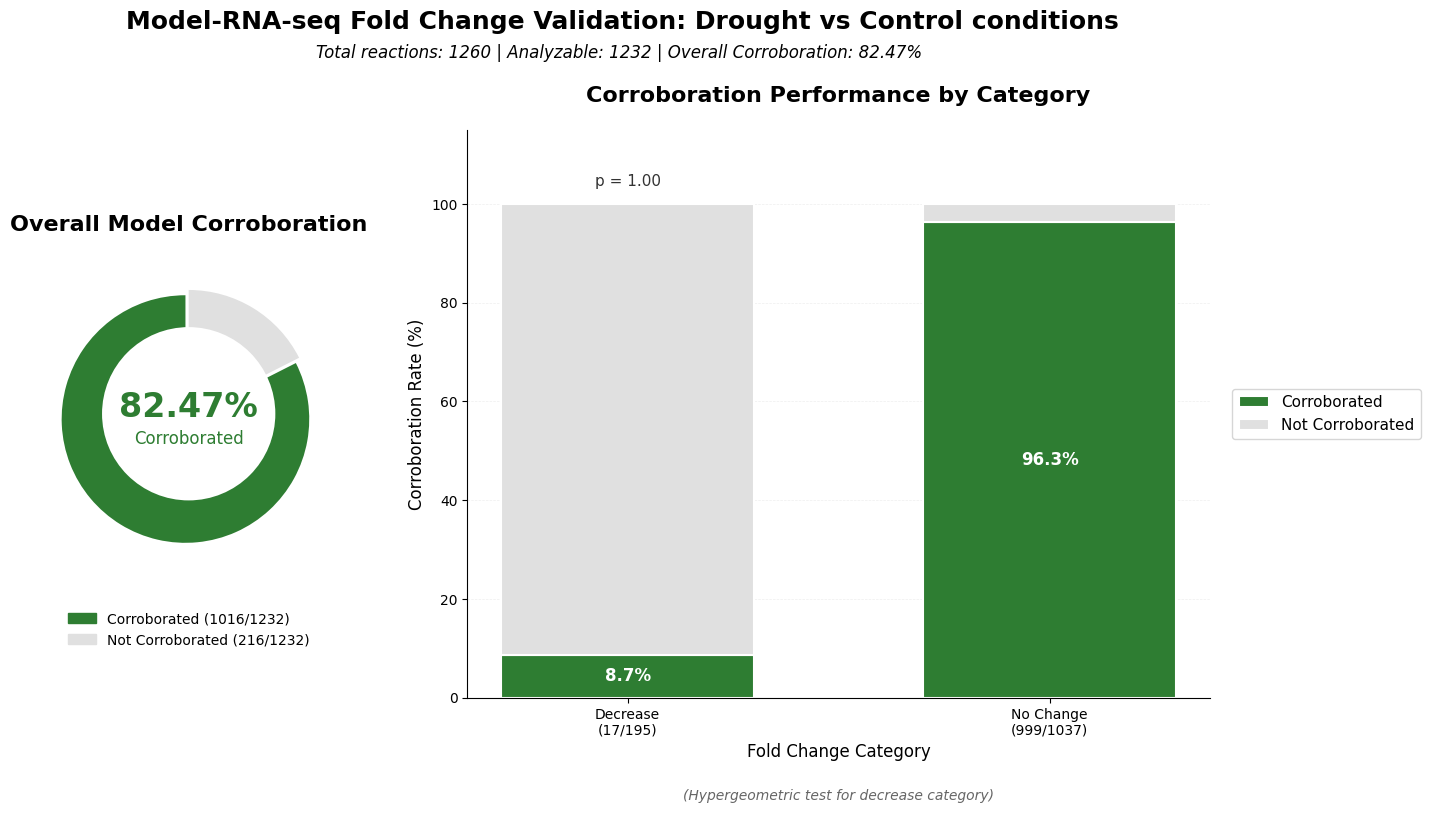

In [2]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Circle
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec

# Set up the figure with a custom layout - increased height
fig = plt.figure(figsize=(14, 8))

# Define color scheme
validated_color = '#2E7D32'  # Dark green
not_validated_color = '#E0E0E0'  # Light gray

# Your data
total_reactions = 1260
analyzable_reactions = 1232
validated_reactions = 1016
validation_pct =  82.47

# Category data with hypergeometric p-values - ONLY -1 AND 0
categories = {
    -1: {'validated': 17, 'total': 195, 'pct': 8.71, 'label': 'Decrease', 'p_value': 1},
    0: {'validated': 999, 'total': 1037, 'pct': 96.3, 'label': 'No Change', 'p_value': 1}
}

# Create custom gridspec for 1/3 and 2/3 width distribution
gs = gridspec.GridSpec(1, 3, figure=fig, wspace=0.4)

# === Panel A: Validation Overview (Donut Chart) - 1/3 width ===
ax1 = fig.add_subplot(gs[0, 0])  # Takes first column

# Donut chart data
sizes = [validation_pct, 100 - validation_pct]
colors = [validated_color, not_validated_color]
explode = (0.05, 0)  # Slightly separate the validated slice

# Create donut
wedges, texts, autotexts = ax1.pie(sizes, colors=colors, labels=['', ''],
                                     autopct='', startangle=90,
                                     explode=explode)

# Make it a donut by adding a white circle in the center
centre_circle = Circle((0, 0), 0.70, fc='white')
ax1.add_artist(centre_circle)

# Add center text with better sizing
ax1.text(0, 0.05, f'{validation_pct}%', ha='center', va='center',
         fontsize=24, weight='bold', color=validated_color)
ax1.text(0, -0.2, 'Corroborated', ha='center', va='center',
         fontsize=12, color=validated_color)

# Add title
ax1.set_title('Overall Model Corroboration', fontsize=16, weight='bold', pad=20)

# Add legend below the donut
legend_elements = [
    mpatches.Patch(color=validated_color, label=f'Corroborated ({validated_reactions}/{analyzable_reactions})'),
    mpatches.Patch(color=not_validated_color, label=f'Not Corroborated ({analyzable_reactions - validated_reactions}/{analyzable_reactions})')
]
ax1.legend(handles=legend_elements, loc='upper center', bbox_to_anchor=(0.5, -0.1),
          ncol=1, fontsize=10, frameon=False)

# === Panel B: Category-Specific Performance with P-values - 2/3 width ===
ax2 = fig.add_subplot(gs[0, 1:])  # Takes columns 2 and 3

# Prepare data for bar chart - ONLY TWO CATEGORIES
categories_list = [-1, 0]
category_labels = [categories[cat]['label'] for cat in categories_list]
# Create labels with counts on second line
category_labels_with_counts = [f"{categories[cat]['label']}\n({categories[cat]['validated']}/{categories[cat]['total']})"
                               for cat in categories_list]
validation_rates = [categories[cat]['pct'] for cat in categories_list]
not_validated_rates = [100 - rate for rate in validation_rates]

# Set up bar positions
x = np.arange(len(categories_list))
width = 0.6

# Create stacked bars with better styling
bars1 = ax2.bar(x, validation_rates, width, label='Corroborated',
                color=validated_color, edgecolor='white', linewidth=1.5)
bars2 = ax2.bar(x, not_validated_rates, width, bottom=validation_rates,
                label='Not Corroborated', color=not_validated_color,
                edgecolor='white', linewidth=1.5)

# Add value labels on bars
for i, (cat, bar) in enumerate(zip(categories_list, bars1)):
    height = bar.get_height()
    # Only add percentage if the bar is tall enough
    if height > 5:
        ax2.text(bar.get_x() + bar.get_width()/2, height/2, f'{height:.1f}%',
                ha='center', va='center', fontsize=12, weight='bold', color='white')

# Add p-values above bars for -1 category only
for i, cat in enumerate(categories_list):
    if cat == -1:  # Only for decrease category
        bar_height = 100  # Use full height since bars are stacked to 100
        p_val = categories[cat]['p_value']

        # Position p-value above the bar
        y_position = bar_height + 3

        # Format p-value text
        if p_val < 0.001:
            p_text = 'p < 0.001'
            fontweight = 'bold'
            color = '#d62728'  # Red for significant
        elif p_val < 0.05:
            p_text = f'p = {p_val:.3f}'
            fontweight = 'bold'
            color = '#d62728'  # Red for significant
        else:
            p_text = f'p = {p_val:.2f}'
            fontweight = 'normal'
            color = '#333333'

        # Add p-value text
        ax2.text(x[i], y_position, p_text,
                ha='center', va='bottom', fontsize=11,
                weight=fontweight, color=color)

# Customize the plot
ax2.set_ylabel('Corroboration Rate (%)', fontsize=12)
ax2.set_xlabel('Fold Change Category', fontsize=12)
ax2.set_title('Corroboration Performance by Category', fontsize=16, weight='bold', pad=20)
ax2.text(0.5, -0.18, '(Hypergeometric test for decrease category)',
         transform=ax2.transAxes, ha='center', fontsize=10, style='italic', color='#666666')
ax2.set_xticks(x)
ax2.set_xticklabels(category_labels_with_counts)
ax2.set_ylim(0, 115)  # To accommodate p-value labels
# Move legend to the right side, outside the plot area
ax2.legend(loc='center left', frameon=True, fancybox=True, shadow=False,
           bbox_to_anchor=(1.02, 0.5), fontsize=11)

# Add subtle grid for better readability
ax2.grid(True, axis='y', alpha=0.2, linestyle='--', linewidth=0.5)
ax2.set_axisbelow(True)  # Put grid behind bars

# Make the plot look cleaner
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

# === Overall figure adjustments ===
# Add main title with proper spacing
fig.suptitle('Model-RNA-seq Fold Change Validation: Drought vs Control conditions',
             fontsize=18, weight='bold', y=0.98)

# Add subtitle with key stats
fig.text(0.5, 0.92,
         f'Total reactions: {total_reactions} | Analyzable: {analyzable_reactions} | ' +
         f'Overall Corroboration: {validation_pct}% ',
         ha='center', fontsize=12, style='italic')

# Manual spacing adjustment - adjusted right margin to make room for legend
plt.subplots_adjust(left=0.08, right=0.92, top=0.83, bottom=0.12, wspace=0.4)

# Optional: Save the figure
plt.savefig('model_validation_dashboard_with_pvalues.png', dpi=300, bbox_inches='tight')
plt.savefig('model_validation_dashboard_with_pvalues.pdf', bbox_inches='tight')  # For publication
plt.show()